# BukaToko  —  Funnel Conversion Analysis

E-commerce clickstream case study. Goal: understand user activity across countries/channels
and improve funnel conversion (browse â†’ add to cart â†’ checkout â†’ purchase).


## STEP 00  —  Setup

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from IPython.display import HTML

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

# Fixed categorical palette -- "bee" tone (yellow/gold -> black), fixed order, never
# cycled/reassigned. Slot 0 (bright yellow) is the brand accent, used to highlight
# "the answer" bar in a chart; the rest of the family (amber/honey/olive/straw/grey/black)
# carries the remaining categories so every chart in the notebook reads as one system.
CAT = ['#F5C518', '#1c1c1c', '#E8A400', '#5c5c52', '#A67C00', '#6b6b1a', '#F2DA8C', '#000000']
BEE_YELLOW, BEE_BLACK, BEE_AMBER, BEE_GREY, BEE_HONEY, BEE_OLIVE, BEE_STRAW, BEE_JET = CAT
BRAND_YELLOW = BEE_YELLOW

# Sequence blue is kept as-is -- explicitly exempted from the bee reskin. Used only for
# continuous/sequential magnitude ramps (heatmaps, the funnel-stage ordinal ramp, the
# top-products volume ramp), never as a categorical or highlight color.
BLUE = '#2a78d6'
SEQ_BLUE = ['#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95', '#0d366b']

def blend_with_white(hex_color, t):
    """t in [0,1]: 0 -> white, 1 -> full hex_color. Builds a one-hue sequential ramp on demand."""
    r, g, b = int(hex_color[1:3], 16), int(hex_color[3:5], 16), int(hex_color[5:7], 16)
    r = int(255 + (r - 255) * t)
    g = int(255 + (g - 255) * t)
    b = int(255 + (b - 255) * t)
    return f'#{r:02x}{g:02x}{b:02x}'

def blend_two(c1, c2, t):
    """t in [0,1]: 0 -> c1, 1 -> c2. Two-stop hex interpolation -- used for the bee
    yellow -> black magnitude ramps (hotness scales, severity gradients)."""
    r1, g1, b1 = int(c1[1:3], 16), int(c1[3:5], 16), int(c1[5:7], 16)
    r2, g2, b2 = int(c2[1:3], 16), int(c2[3:5], 16), int(c2[5:7], 16)
    r = int(r1 + (r2 - r1) * t)
    g = int(g1 + (g2 - g1) * t)
    b = int(b1 + (b2 - b1) * t)
    return f'#{r:02x}{g:02x}{b:02x}'

DATA_PATH = '../data/Dataset Case Study - dirty_dummy_events.csv'
raw = pd.read_csv(DATA_PATH)
print('Raw shape:', raw.shape)
raw.head()


Raw shape: (10000, 9)


,event_id,user_id,session_id,event_type,event_timestamp,product_id,country,device,channel
0,9bd8725f-5722-41b7-8d95-a5dafec33a56,482c0ae4-ac6c-4eb3-91fe-b0e63c1c2a5d,98b232db-5bec-41d8-88e1-5d2e98899e29,product_view,2025-09-22 16:35:27,P1208,US,IOS,paid_search
1,f6dc704c-a88c-4668-b89d-e6b08e7e02d4,ff6c808d-fa75-4202-801f-a076299a2c0f,d4832af2-0aad-489c-8eb6-22d243f5f5c4,page_view,2025-06-04 21:55:04,NaN,ID,android,referral
2,abb69be8-df83-420b-92f7-149d29a6d32f,78ea2c10-e824-4b3c-b74b-cdb0cbab0610,1f6c5b12-6c79-4b29-bae6-878804723e55,page_view,2025-06-24 2:02:51,NaN,AU,IOS,paid_search
3,76fd2399-0f80-4184-8802-90dac9bf52d3,9c63419c-b3dc-44a6-b8a5-a438e82afee8,ed1c4ded-cf67-463e-b94f-4cebcf62d827,page_view,2025-06-05 12:35:33,NaN,VN,IOS,organic
4,26dcc5fa-334c-420c-be1e-a40eb4b9efac,f9aee3bb-2ba4-4bb3-9eec-44ba4664f93b,9a469fb9-6cf4-4818-b0a6-7302b0bd665a,product_view,2025-07-02 12:19:23,P1315,ID,desktop,social


## STEP 01  —  Data Quality Audit

In [54]:
print(raw.dtypes)
print()
print('--- Missing values ---')
print(raw.isnull().sum())
print('--- Duplicate rows / event_id ---', raw.duplicated().sum(), '/', raw['event_id'].duplicated().sum())


event_id           object
user_id            object
session_id         object
event_type         object
event_timestamp    object
product_id         object
country            object
device             object
channel            object
dtype: object

--- Missing values ---
event_id              0
user_id               0
session_id            0
event_type            0
event_timestamp       0
product_id         5537
country               0
device                0
channel             100
dtype: int64
--- Duplicate rows / event_id --- 0 / 0


In [55]:
events_per_session = raw.groupby('session_id').size()
print('Unique sessions:', raw['session_id'].nunique(), '/ total rows:', len(raw))
print('Avg events per session:', events_per_session.mean())


Unique sessions: 10000 / total rows: 10000
Avg events per session: 1.0


- `channel` missing ~1% (100 rows); `device` casing inconsistent (`IOS`/`android`/`desktop`); no duplicate rows.
- **Key structural issue:** every `session_id` = exactly one event -- it can't link
  multi-event journeys. Workaround used below: (`user_id`, calendar date) as a visit proxy
  wherever same-visit logic is needed (DIY 2).


## STEP 02  —  Data Cleaning

In [56]:
df = raw.copy()

df['event_timestamp'] = pd.to_datetime(df['event_timestamp'])

for c in ['event_type', 'country', 'device', 'channel']:
    df[c] = df[c].astype('string').str.strip()

device_map = {'ios': 'iOS', 'android': 'Android', 'desktop': 'Desktop'}
df['device'] = df['device'].str.lower().map(device_map)

df['channel'] = df['channel'].fillna('unknown')  # ~1% unattributed -- kept, not guessed

df['date'] = df['event_timestamp'].dt.date
df['year_month'] = df['event_timestamp'].dt.to_period('M').astype(str)

# Funnel stage: page_view/search/product_view are all pre-commitment discovery (stage 1);
# login/logout are session housekeeping, not funnel steps (left NaN, dropped later).
funnel_order = {
    'page_view': 1, 'search': 1, 'product_view': 1,
    'add_to_cart': 2, 'checkout': 3, 'purchase': 4,
}
stage_names = {1: 'Browse', 2: 'Add to Cart', 3: 'Checkout', 4: 'Purchase'}
df['funnel_stage'] = df['event_type'].map(funnel_order)

# Fixed color per category (alphabetical order -> CAT slots), reused in every chart
# below so e.g. "email" is always the same color wherever channel appears.
CHANNEL_COLORS = {c: CAT[i] for i, c in enumerate(sorted(df['channel'].unique()))}
DEVICE_COLORS = {d: CAT[i] for i, d in enumerate(sorted(df['device'].unique()))}
DOW_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
DOW_COLORS = {d: CAT[i] for i, d in enumerate(DOW_ORDER)}
STAGE_RAMP = [SEQ_BLUE[1], SEQ_BLUE[3], SEQ_BLUE[4], SEQ_BLUE[6]]  # ordinal ramp, Browse -> Purchase

# Country gets its own high-contrast qualitative palette (not the bee family) -- 8
# countries need to stay strongly, unambiguously distinct wherever they're used as bar/
# line colors or row labels. Okabe-Ito colorblind-safe set: punchier and more mutually
# separable than a default tab10, especially at small chart sizes.
COUNTRY_PALETTE = ['#0072B2', '#E69F00', '#009E73', '#D55E00', '#CC79A7', '#56B4E9', '#F0E442', '#000000']
COUNTRY_COLORS = {c: COUNTRY_PALETTE[i] for i, c in enumerate(sorted(df['country'].unique()))}

# Cleaned but NOT date-scoped -- STEP 04 trims `df` to full months only, but a couple of
# analyses (e.g. STEP 08's same-day check) don't need a full-month window and would only
# lose valid same-day pairs by dropping partial March, so they use this instead.
df_all_dates = df.copy()

print('Clean shape:', df.shape)
df.head()


Clean shape: (10000, 12)


,event_id,user_id,session_id,event_type,event_timestamp,product_id,country,device,channel,date,year_month,funnel_stage
0,9bd8725f-5722-41b7-8d95-a5dafec33a56,482c0ae4-ac6c-4eb3-91fe-b0e63c1c2a5d,98b232db-5bec-41d8-88e1-5d2e98899e29,product_view,2025-09-22 16:35:27,P1208,US,iOS,paid_search,2025-09-22,2025-09,1.0
1,f6dc704c-a88c-4668-b89d-e6b08e7e02d4,ff6c808d-fa75-4202-801f-a076299a2c0f,d4832af2-0aad-489c-8eb6-22d243f5f5c4,page_view,2025-06-04 21:55:04,NaN,ID,Android,referral,2025-06-04,2025-06,1.0
2,abb69be8-df83-420b-92f7-149d29a6d32f,78ea2c10-e824-4b3c-b74b-cdb0cbab0610,1f6c5b12-6c79-4b29-bae6-878804723e55,page_view,2025-06-24 02:02:51,NaN,AU,iOS,paid_search,2025-06-24,2025-06,1.0
3,76fd2399-0f80-4184-8802-90dac9bf52d3,9c63419c-b3dc-44a6-b8a5-a438e82afee8,ed1c4ded-cf67-463e-b94f-4cebcf62d827,page_view,2025-06-05 12:35:33,NaN,VN,iOS,organic,2025-06-05,2025-06,1.0
4,26dcc5fa-334c-420c-be1e-a40eb4b9efac,f9aee3bb-2ba4-4bb3-9eec-44ba4664f93b,9a469fb9-6cf4-4818-b0a6-7302b0bd665a,product_view,2025-07-02 12:19:23,P1315,ID,Desktop,social,2025-07-02,2025-07,1.0


## STEP 03 — Event Type Funnel Order Overview
Full clickstream journey by volume: **login** (session start) -> **browse** (`page_view`,
`search`, `product_view`) -> **add_to_cart** -> **checkout** -> **purchase** -> **logout**
(session end). Bar length = total occurrences of that event across the whole dataset;
color groups events by the funnel stage they belong to (grey = session housekeeping,
not part of the conversion funnel -- see STEP 02).

In [57]:
EVENT_ORDER = ['login', 'page_view', 'search', 'product_view', 'add_to_cart', 'checkout', 'purchase', 'logout']
EVENT_STAGE_COLOR = {
    'login': BEE_GREY, 'logout': BEE_GREY,                                                # housekeeping
    'page_view': STAGE_RAMP[0], 'search': STAGE_RAMP[0], 'product_view': STAGE_RAMP[0],    # Browse
    'add_to_cart': STAGE_RAMP[1],                                                          # Add to Cart
    'checkout': STAGE_RAMP[2],                                                             # Checkout
    'purchase': STAGE_RAMP[3],                                                             # Purchase
}

event_counts = df['event_type'].value_counts().reindex(EVENT_ORDER)
event_labels = [e.replace('_', ' ').title() for e in EVENT_ORDER]
event_colors = [EVENT_STAGE_COLOR[e] for e in EVENT_ORDER]

fig = go.Figure(go.Bar(
    x=event_counts.values, y=event_labels, orientation='h',
    marker_color=event_colors, text=event_counts.values, textposition='outside',
))
fig.update_layout(
    title='Event Type Volume, in Funnel Order (top -> bottom = journey order)',
    xaxis_title='Event count', yaxis={'autorange': 'reversed'},
    showlegend=False, height=420, width=700,
    plot_bgcolor='#fcfcfb', paper_bgcolor='#fcfcfb',
)
HTML(fig.to_html(full_html=False, include_plotlyjs='cdn'))


## STEP 04 — Scope: Drop Partial March
Data starts 2025-03-27, so March is a partial month that would distort month-level
comparisons. Trim to full months, starting **2025-04-01**. September is also partial
(data ends 2025-09-23) -- kept, but see the forecast in STEP 06.

In [58]:
before_rows = len(df)
df = df[df['event_timestamp'] >= '2025-04-01'].reset_index(drop=True)
print(f'Rows: {before_rows} -> {len(df)} (dropped {before_rows - len(df)} March rows)')
print('New date range:', df['event_timestamp'].min(), '->', df['event_timestamp'].max())


Rows: 10000 -> 9761 (dropped 239 March rows)
New date range: 2025-04-01 00:05:30 -> 2025-09-23 11:37:29


## STEP 05 — Q1: Which country has the most Monthly Active Users in Q2 2025 (Apr–Jun)?
Active user = distinct `user_id` with >=1 event. Q2 2025 = **[2025-04-01, 2025-07-01)**.

In [59]:
q2_2025 = df[(df['event_timestamp'] >= '2025-04-01') & (df['event_timestamp'] < '2025-07-01')]
active_users_by_country = (
    q2_2025.groupby('country')['user_id'].nunique().sort_values(ascending=False).rename('active_users')
)
active_users_by_country


country
ID    1055
US     815
VN     485
PH     464
MY     460
SG     459
TH     236
AU     215
Name: active_users, dtype: int64

In [60]:
def flag_url(code):
    # Unicode regional-indicator flag emoji don't render on Windows (no flag glyphs
    # shipped in its emoji font), so pull an actual flag icon from a public flag CDN
    # instead and place it as a layout image under each bar.
    return f'https://flagcdn.com/h40/{code.lower()}.png'

order = active_users_by_country
top_country = order.idxmax()
labels = list(order.index)
colors = [BRAND_YELLOW if c == top_country else SEQ_BLUE[2] for c in order.index]

fig = go.Figure(go.Bar(x=labels, y=order.values, marker_color=colors,
                        text=order.values, textposition='outside'))
fig.update_layout(
    title=dict(text=('Distinct Active Users by country <br>'
                      '<sup>1 Apr 2025 – 30 Jun 2025 (Q2 2025)</sup>')),
    yaxis_title='Active users',
    showlegend=False, height=480, width=650,
    margin=dict(b=120, t=90),
    plot_bgcolor='#fcfcfb', paper_bgcolor='#fcfcfb',
    images=[
        dict(source=flag_url(c), xref='x', x=c, yref='paper', y=-0.08,
             sizex=0.6, sizey=0.16, xanchor='center', yanchor='top',
             sizing='contain', layer='above')
        for c in order.index
    ],
)
HTML(fig.to_html(full_html=False, include_plotlyjs='cdn'))


**Answer:** Indonesia (**ID**) -- most active users in Q2 2025, well ahead of US and Vietnam.

## STEP 06 — Q2: Monthly Active Users Trend by Channel
Small multiples (one panel per channel) instead of one crowded overlapping-line chart.
September is partial (23 of 30 days) -- shown as-is, plus a proportional forecast
(`actual * 30/23`) to estimate the full month.

In [61]:
mau_channel = df.groupby(['year_month', 'channel'])['user_id'].nunique().reset_index(name='active_users')
pivot = mau_channel.pivot(index='year_month', columns='channel', values='active_users').fillna(0).sort_index()

days_elapsed = df['event_timestamp'].max().day  # 23
forecast_multiplier = 30 / days_elapsed
sep_forecast = (pivot.loc['2025-09'] * forecast_multiplier).round(0)

summary = pivot.copy()
summary.loc['2025-09 (forecast)'] = sep_forecast
summary


channel,direct,email,organic,paid_search,referral,social,unknown
year_month,,,,,,,
2025-04,262.0,258.0,260.0,255.0,244.0,276.0,15.0
2025-05,270.0,284.0,251.0,259.0,244.0,268.0,13.0
2025-06,271.0,263.0,259.0,258.0,289.0,262.0,15.0
2025-07,257.0,290.0,268.0,288.0,255.0,250.0,15.0
2025-08,250.0,248.0,249.0,251.0,292.0,240.0,20.0
2025-09,186.0,209.0,208.0,206.0,197.0,174.0,20.0
2025-09 (forecast),243.0,273.0,271.0,269.0,257.0,227.0,26.0


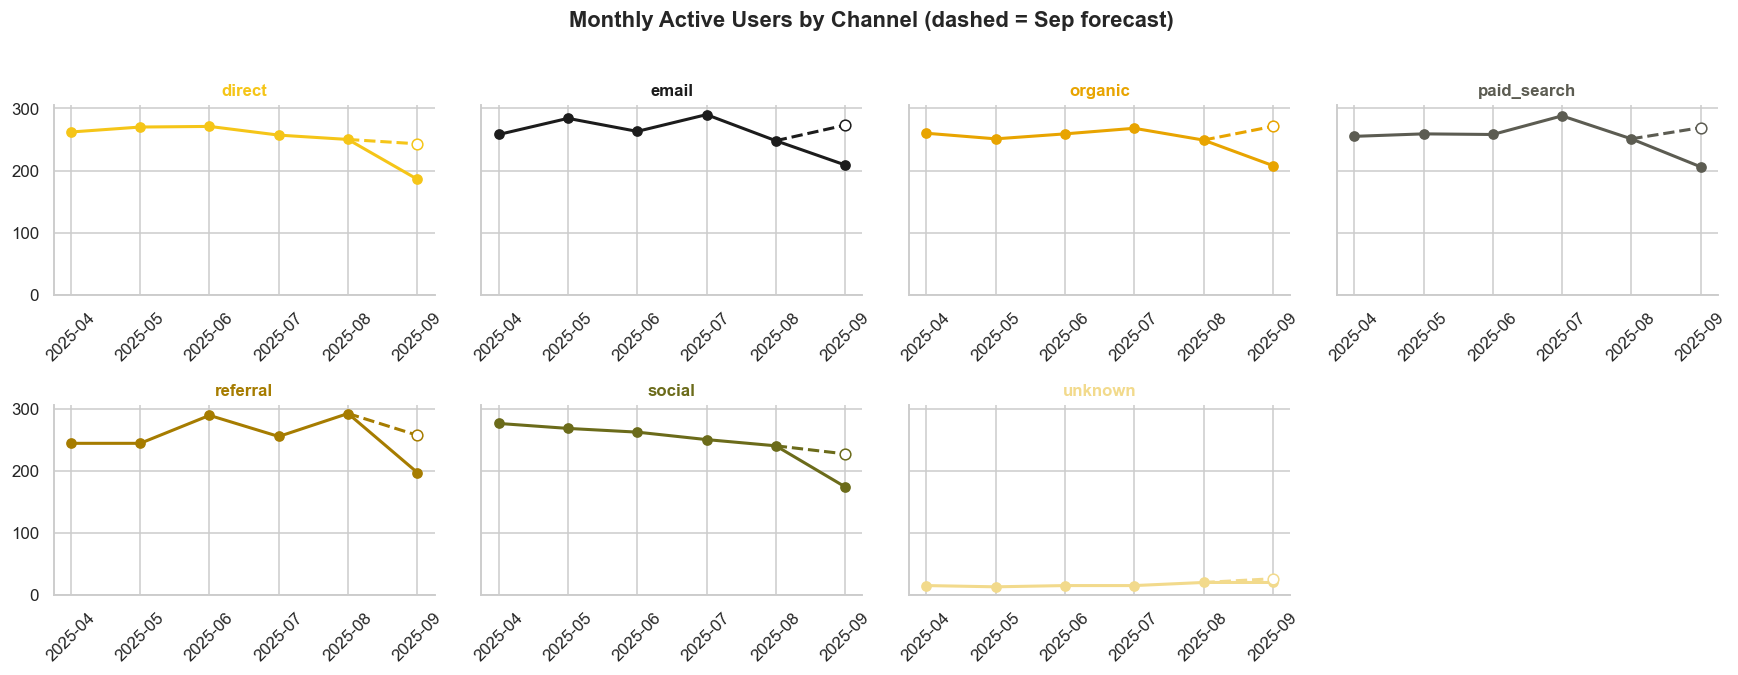

In [62]:
x_actual = pivot.index.tolist()
ncols = 4
nrows = int(np.ceil(len(pivot.columns) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharey=True)
axes = axes.flatten()
for ax, ch in zip(axes, pivot.columns):
    c = CHANNEL_COLORS[ch]
    y_actual = pivot[ch].values
    ax.plot(x_actual, y_actual, marker='o', color=c, linewidth=2)
    ax.plot([x_actual[-2], '2025-09'], [y_actual[-2], sep_forecast[ch]],
            color=c, linewidth=2, linestyle='--')
    ax.plot(['2025-09'], [sep_forecast[ch]], marker='o', markerfacecolor='white',
             markeredgecolor=c, markersize=7, zorder=5)
    ax.set_title(ch, fontsize=11, fontweight='bold', color=c)
    ax.tick_params(axis='x', rotation=45)
for ax in axes[len(pivot.columns):]:
    ax.axis('off')
fig.suptitle('Monthly Active Users by Channel (dashed = Sep forecast)', fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.show()


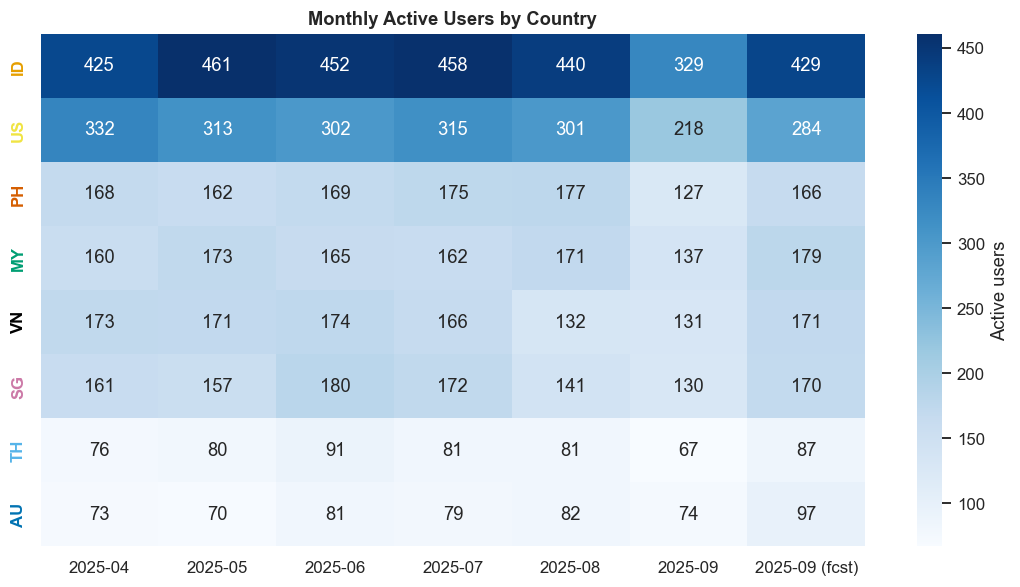

In [63]:
# Granular: same MAU trend, split by country, as a heatmap (rows ordered by total
# volume, high -> low).
mau_country = df.groupby(['year_month', 'country'])['user_id'].nunique().reset_index(name='active_users')
pivot_c = mau_country.pivot(index='year_month', columns='country', values='active_users').fillna(0).sort_index()
country_order_mau = pivot_c.sum().sort_values(ascending=False).index.tolist()
sep_forecast_c = (pivot_c.loc['2025-09'] * forecast_multiplier).round(0)

heat_mau = pivot_c.T.loc[country_order_mau]
heat_mau['2025-09 (fcst)'] = sep_forecast_c.reindex(country_order_mau)

fig, ax = plt.subplots(figsize=(10, 0.5 * len(country_order_mau) + 1.5))
sns.heatmap(heat_mau, annot=True, fmt='.0f', cmap='Blues', ax=ax, cbar_kws={'label': 'Active users'})
ax.set_title('Monthly Active Users by Country', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
for tick, country in zip(ax.get_yticklabels(), country_order_mau):
    tick.set_color(COUNTRY_COLORS[country])
    tick.set_fontweight('bold')
plt.tight_layout()
plt.show()


## STEP 07 — DIY 1: Most-used device (by session), and where each device's users end their journey

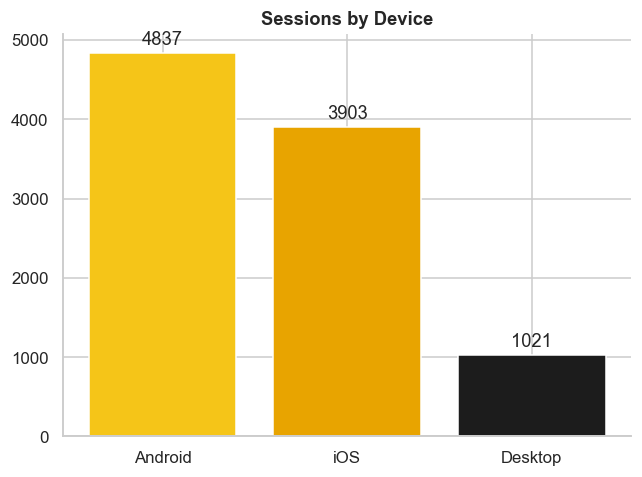

Most used device: Android (4837 sessions, 49.6% of all sessions)


In [64]:
device_sessions = df.groupby('device')['session_id'].nunique().sort_values(ascending=False)
top_device = device_sessions.idxmax()
colors = [BRAND_YELLOW if d == top_device else DEVICE_COLORS[d] for d in device_sessions.index]

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(device_sessions.index, device_sessions.values, color=colors)
ax.bar_label(bars, padding=3)
ax.set_title('Sessions by Device', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

share = device_sessions.max() / device_sessions.sum()
print(f'Most used device: {top_device} ({device_sessions.max()} sessions, {share:.1%} of all sessions)')


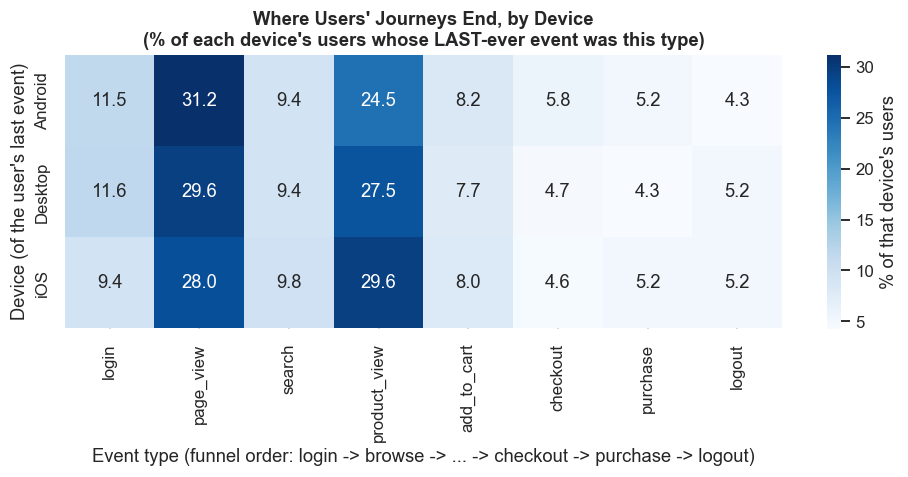

In [65]:
# Device isn't fixed per user (most users appear on 2-3 different devices), so "device
# share within an event_type" mixes users together and just reflects the overall device
# mix. Instead: take each user's single LATEST event overall, and look at which device it
# happened on -- this shows where each device's users tend to end their journey. Rows are
# devices, columns follow the funnel order defined in STEP 03 (login -> browse -> cart ->
# checkout -> purchase -> logout).
latest_idx = df.groupby('user_id')['event_timestamp'].idxmax()
latest_events = df.loc[latest_idx, ['user_id', 'device', 'event_type']]

device_last_event = pd.crosstab(latest_events['device'], latest_events['event_type'], normalize='index') * 100
device_last_event = device_last_event.reindex(columns=EVENT_ORDER)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(device_last_event.round(1), annot=True, fmt='.1f', cmap='Blues', ax=ax,
            cbar_kws={'label': "% of that device's users"})
ax.set_title("Where Users' Journeys End, by Device\n(% of each device's users whose LAST-ever event was this type)", fontweight='bold')
ax.set_xlabel('Event type (funnel order: login -> browse -> ... -> checkout -> purchase -> logout)')
ax.set_ylabel("Device (of the user's last event)")
plt.tight_layout()
plt.show()


**Answer:** Android is the most-used device overall. Looking at where each device's users'
journeys actually end (their last-ever event), the pattern is the same across all three
devices: **~65-67% end mid-Browse** (`page_view`/`search`/`product_view`) and only
**~4-5% end at Purchase**, regardless of device. Device doesn't gate how far a user gets
in the funnel -- the drop-off is a browse-stage problem everywhere, not a device-specific
one.

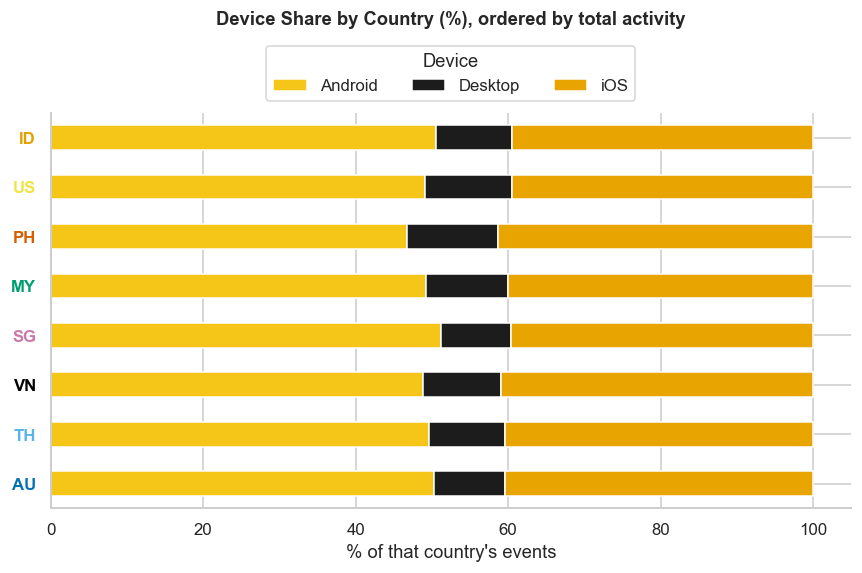

In [78]:
# Granular: device mix split by country, as a 100%-stacked bar (composition-by-category
# reads more directly this way than as a heatmap). Rows ordered by total activity,
# high -> low.
country_activity_order = df['country'].value_counts().index.tolist()
device_by_country = pd.crosstab(df['country'], df['device']).reindex(country_activity_order)
device_share_by_country = device_by_country.div(device_by_country.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 0.5 * len(country_activity_order) + 1.5))
device_share_by_country.plot(kind='barh', stacked=True, ax=ax,
                              color=[DEVICE_COLORS[d] for d in device_share_by_country.columns])
ax.invert_yaxis()
ax.set_title('Device Share by Country (%), ordered by total activity', y=1.2, fontweight='bold')
ax.set_xlabel("% of that country's events")
ax.set_ylabel('')
for tick, country in zip(ax.get_yticklabels(), country_activity_order):
    tick.set_color(COUNTRY_COLORS[country])
    tick.set_fontweight('bold')
ax.legend(title='Device', bbox_to_anchor=(0.5, 1.1), loc='center', ncol=3)
sns.despine()
plt.tight_layout()
plt.show()


## STEP 08 — DIY 2: Search → Add-to-Cart same-day conversion
Same `user_id` + calendar date, add_to_cart timestamp strictly after search timestamp.

In [ ]:
# Uses df_all_dates (STEP 02, before the STEP 04 March trim) -- this is a same-day,
# within-day comparison, so a full calendar month isn't needed, and dropping March would
# only throw away potentially valid same-day pairs for no reason.
#
# Every `search` event is a candidate (not just the user's first search that day) -- what
# matters is whether ANY search on a given day is followed by an add_to_cart later that
# same day, not specifically the first one.
searches = df_all_dates[df_all_dates['event_type'] == 'search'][['user_id', 'date', 'event_timestamp']].rename(columns={'event_timestamp': 'search_time'})
atc_all = df_all_dates[df_all_dates['event_type'] == 'add_to_cart'][['user_id', 'date', 'event_timestamp']].rename(columns={'event_timestamp': 'atc_time'})

# Every search paired with every add_to_cart sharing the same user_id + date (a user-day
# can match 0, 1, or several add_to_cart rows; 0 matches -> atc_time = NaT).
merged = searches.merge(atc_all, on=['user_id', 'date'], how='left')
# "converted" = that add_to_cart happened strictly after THAT search (NaT comparisons
# evaluate to False, so unmatched rows are correctly not converted).
merged['converted'] = merged['atc_time'] > merged['search_time']
# Collapse back to one row per user-day -- a day counts as converted if ANY search-then-
# add_to_cart pair on it qualified (not just one anchored on the first search).
converted_flag = merged.groupby(['user_id', 'date'])['converted'].any().reset_index()

total_search_days = converted_flag.shape[0]
converted_days = converted_flag['converted'].sum()
print(f'User-days with search: {total_search_days} | converted (same-day ATC after any search): {converted_days} '
      f'({converted_days/total_search_days:.2%})')


User-days with search: 945 | converted (same-day ATC after any search): 1 (0.11%)


**Answer:** ~0.1% (1 of 945). Negligible -- this dataset is too sparse (STEP 01) for
same-day search-to-cart to be a meaningful signal.

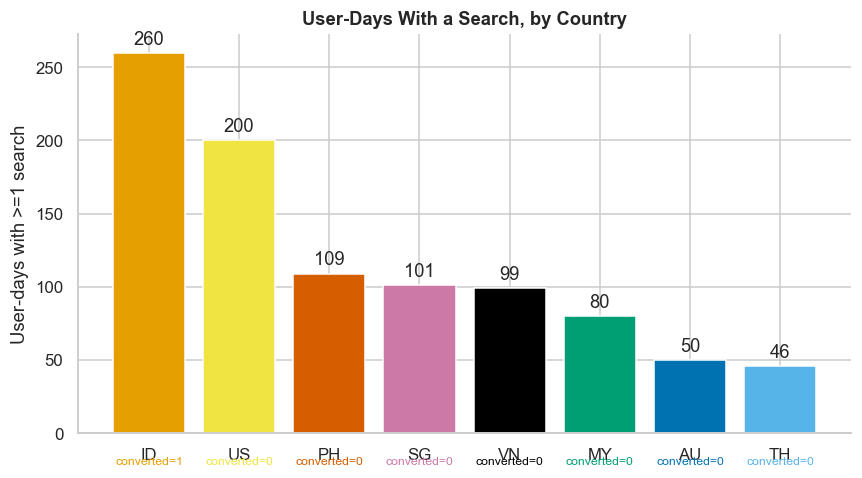

In [ ]:
# Granular: same-day conversion by country, as a bar chart (volume), annotated with
# the converted count. Sample is razor-thin (2 converted user-days total across ALL
# countries) -- directional only, not a reliable signal.
searches_c = df_all_dates[df_all_dates['event_type'] == 'search'][['user_id', 'date', 'country', 'event_timestamp']].rename(columns={'event_timestamp': 'search_time'})
merged_c = searches_c.merge(atc_all, on=['user_id', 'date'], how='left')
merged_c['converted'] = merged_c['atc_time'] > merged_c['search_time']
flag_c = merged_c.groupby(['user_id', 'date', 'country'])['converted'].any().reset_index()

conv_by_country = flag_c.groupby('country').agg(user_days=('converted', 'size'), converted=('converted', 'sum'))
conv_by_country = conv_by_country.sort_values('user_days', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(conv_by_country.index, conv_by_country['user_days'],
              color=[COUNTRY_COLORS[c] for c in conv_by_country.index])
ax.bar_label(bars, padding=3)
ax.set_title('User-Days With a Search, by Country', fontweight='bold')
ax.set_ylabel('User-days with >=1 search')
for i, country in enumerate(conv_by_country.index):
    conv = int(conv_by_country.loc[country, 'converted'])
    ax.text(i, ax.get_ylim()[1] * -0.06, f'converted={conv}', ha='center', va='top',
            fontsize=8, color=COUNTRY_COLORS[country])
sns.despine()
plt.tight_layout()
plt.show()


**Which event contributes most to a same-day add-to-cart?** Broader than the search-only
check above: for every `add_to_cart` event, look at ANY other event by the same user on
the same calendar date that happened earlier that day, and attribute the cart-add to the
closest one (its immediate same-day trigger).

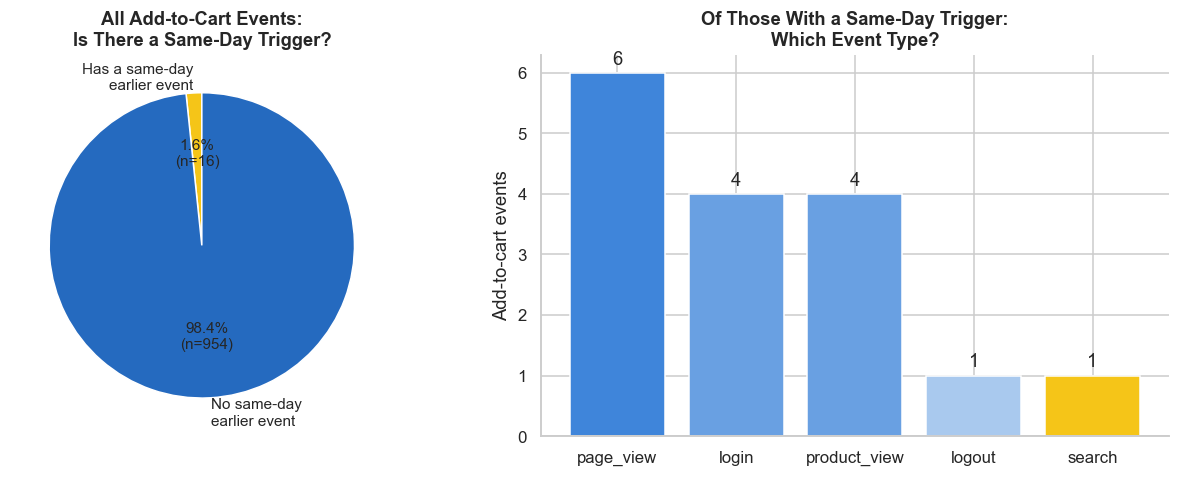

16 / 970 add-to-cart events (1.6%) have ANY same-day earlier event at all.
Top contributor: page_view (6 of 16 attributable events)


In [ ]:
# Uses df_all_dates for the same reason as the search check above (same-day comparison,
# no need to drop partial March). event_id is the join key so each add_to_cart row is
# attributed exactly once, even if a user has several cart-adds the same day.
atc_events = df_all_dates[df_all_dates['event_type'] == 'add_to_cart'][['event_id', 'user_id', 'date', 'event_timestamp']].rename(columns={'event_timestamp': 'atc_time'})
other_events = df_all_dates[df_all_dates['event_type'] != 'add_to_cart'][['user_id', 'date', 'event_timestamp', 'event_type']].rename(columns={'event_timestamp': 'other_time'})

same_day = atc_events.merge(other_events, on=['user_id', 'date'], how='left')
same_day = same_day[same_day['other_time'] < same_day['atc_time']]  # strictly before, same calendar date

closest_idx = same_day.groupby('event_id')['other_time'].idxmax()
closest_trigger = same_day.loc[closest_idx]

contribution = closest_trigger['event_type'].value_counts()
same_day_n = len(closest_trigger)
diff_day_n = len(atc_events) - same_day_n

# Left: of ALL add-to-cart events, how many have a same-day earlier event at all --
# yellow highlights that (small) slice, the rest is a solid "sequence blue" rather than
# grey (more visible against a white background).
# Right: of THOSE, which event type was the closest trigger -- search stays yellow
# (what the original DIY 2 question asks about), every other event type gets a blue
# gradient scaled by its own count.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].pie([same_day_n, diff_day_n],
            labels=['Has a same-day\nearlier event', 'No same-day\nearlier event'],
            autopct=lambda p: f'{p:.1f}%\n(n={round(p / 100 * len(atc_events))})',
            colors=[BRAND_YELLOW, SEQ_BLUE[4]], startangle=90, textprops={'fontsize': 10})
axes[0].set_title('All Add-to-Cart Events:\nIs There a Same-Day Trigger?', fontweight='bold')

blue_norm = (contribution.values - contribution.values.min()) / (contribution.values.max() - contribution.values.min() + 1e-9)
bar_colors = [BRAND_YELLOW if e == 'search' else blend_with_white(BLUE, 0.4 + 0.5 * n)
              for e, n in zip(contribution.index, blue_norm)]
bars = axes[1].bar(contribution.index, contribution.values, color=bar_colors)
axes[1].bar_label(bars, padding=3)
axes[1].set_title('Of Those With a Same-Day Trigger:\nWhich Event Type?', fontweight='bold')
axes[1].set_ylabel('Add-to-cart events')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

print(f'{same_day_n} / {len(atc_events)} add-to-cart events ({same_day_n / len(atc_events):.1%}) '
      'have ANY same-day earlier event at all.')
print(f'Top contributor: {contribution.idxmax()} ({contribution.max()} of {same_day_n} attributable events)')


**Answer:** Only ~1.7% of all add-to-cart events have ANY other event earlier the same
day at all -- the same sparsity limitation as the search check above. Among that small
attributable set, `page_view` is the top contributor.

## STEP 09 — Funnel Conversion Overview
Funnel: **Browse -> Add to Cart -> Checkout -> Purchase**. Per user, take the highest
stage ever reached.

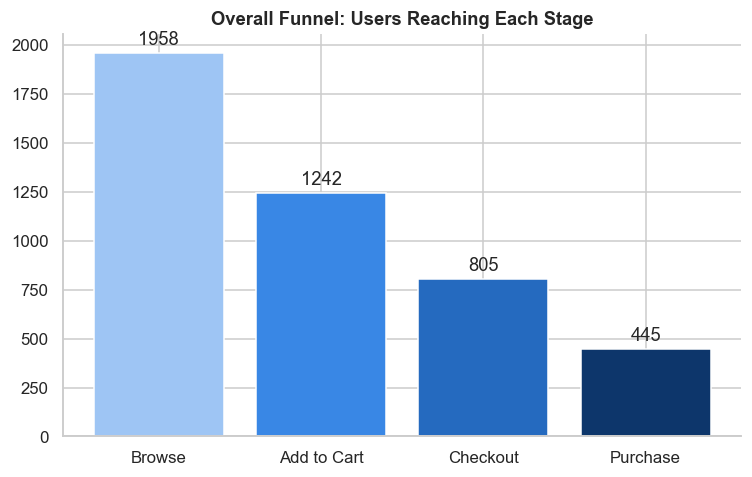

Browse -> Add to Cart: 63.4%
Add to Cart -> Checkout: 64.8%
Checkout -> Purchase: 55.3%
Overall Browse -> Purchase: 22.73%


In [ ]:
user_max_stage = df.dropna(subset=['funnel_stage']).groupby('user_id')['funnel_stage'].max()
funnel_counts = pd.Series({stage_names[s]: (user_max_stage >= s).sum() for s in [1, 2, 3, 4]})

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(funnel_counts.index, funnel_counts.values, color=STAGE_RAMP)
ax.bar_label(bars, padding=3)
ax.set_title('Overall Funnel: Users Reaching Each Stage', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

stages = list(funnel_counts.index)
for i in range(1, len(stages)):
    print(f'{stages[i-1]} -> {stages[i]}: {funnel_counts[stages[i]] / funnel_counts[stages[i-1]]:.1%}')
print(f"Overall Browse -> Purchase: {funnel_counts['Purchase'] / funnel_counts['Browse']:.2%}")


In [ ]:
# Alternative view of the same numbers as a funnel chart. Count and its percentage of
# the initial (Browse) stage are shown together, side by side, in one label per segment.
fig = go.Figure(go.Funnel(
    y=funnel_counts.index,
    x=funnel_counts.values,
    texttemplate='%{value:,} (%{percentInitial})',
    textposition='inside',
    marker={'color': STAGE_RAMP},
    connector={'line': {'color': '#cccccc', 'width': 1}},
))
fig.update_layout(
    title=dict(text=('Overall Funnel — by Event Stage<br>'
                      '<sup>Percentage = % of Browse (initial stage)</sup>')),
    height=420, width=650,
    showlegend=False, plot_bgcolor='#fcfcfb', paper_bgcolor='#fcfcfb',
)
HTML(fig.to_html(full_html=False, include_plotlyjs='cdn'))


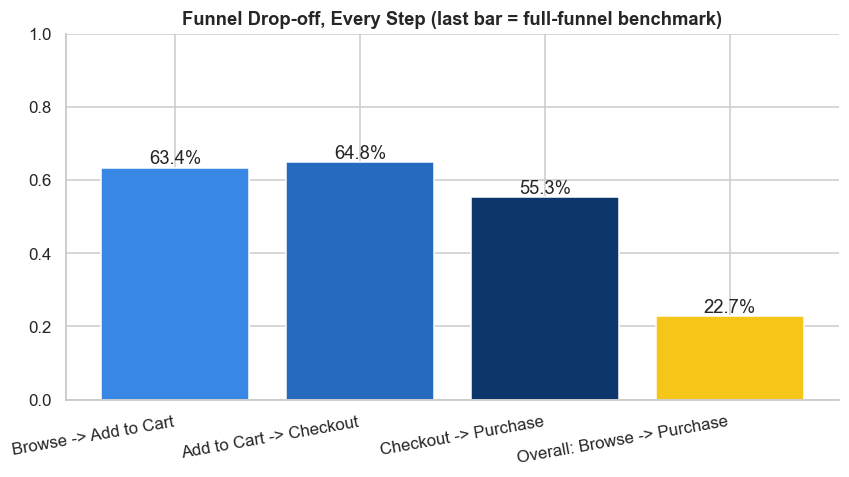

In [ ]:
browse_to_atc = funnel_counts['Add to Cart'] / funnel_counts['Browse']
atc_to_checkout = funnel_counts['Checkout'] / funnel_counts['Add to Cart']
checkout_to_purchase = funnel_counts['Purchase'] / funnel_counts['Checkout']
overall_conversion = funnel_counts['Purchase'] / funnel_counts['Browse']

labels = ['Browse -> Add to Cart', 'Add to Cart -> Checkout', 'Checkout -> Purchase', 'Overall: Browse -> Purchase']
vals = [browse_to_atc, atc_to_checkout, checkout_to_purchase, overall_conversion]
colors = [STAGE_RAMP[1], STAGE_RAMP[2], STAGE_RAMP[3], BRAND_YELLOW]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels, vals, color=colors)
ax.set_ylim(0, 1)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f'{v:.1%}', ha='center', va='bottom')
ax.set_title('Funnel Drop-off, Every Step (last bar = full-funnel benchmark)', fontweight='bold')
plt.xticks(rotation=10, ha='right')
sns.despine()
plt.tight_layout()
plt.show()


Whichever step-to-step bar is lowest is the highest-leverage fix to prioritize
(browse/discovery, cart/pricing/shipping, or payment-flow friction). The last bar
(Overall) is the full-funnel benchmark, not a step to fix on its own.

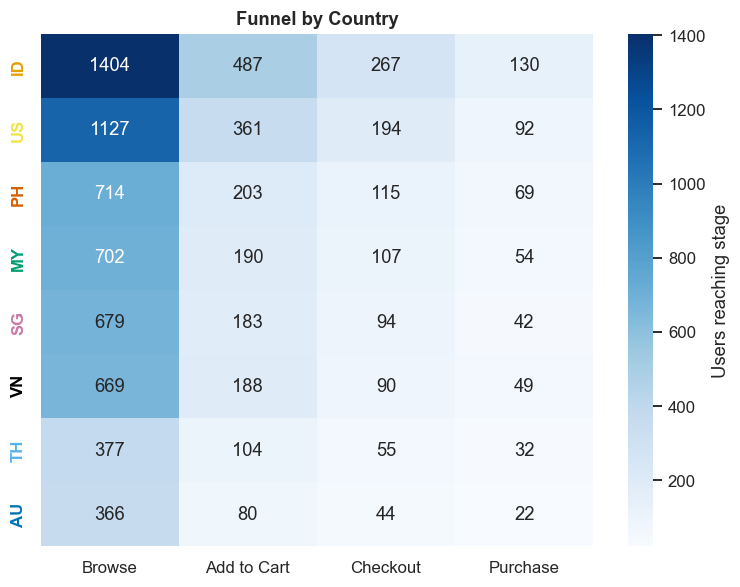

In [ ]:
# Granular: same funnel, split by country, as a heatmap (rows ordered by Browse volume,
# high -> low).
funnel_by_country = {}
for country, g in df.dropna(subset=['funnel_stage']).groupby('country'):
    ums = g.groupby('user_id')['funnel_stage'].max()
    funnel_by_country[country] = pd.Series({stage_names[s]: (ums >= s).sum() for s in [1, 2, 3, 4]})
funnel_country_df = pd.DataFrame(funnel_by_country).T
funnel_country_df = funnel_country_df.loc[funnel_country_df['Browse'].sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(7, 0.5 * len(funnel_country_df) + 1.5))
sns.heatmap(funnel_country_df, annot=True, fmt='.0f', cmap='Blues', ax=ax, cbar_kws={'label': 'Users reaching stage'})
ax.set_title('Funnel by Country', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
for tick, country in zip(ax.get_yticklabels(), funnel_country_df.index):
    tick.set_color(COUNTRY_COLORS[country])
    tick.set_fontweight('bold')
plt.tight_layout()
plt.show()


## STEP 10 — Lead Time per Funnel Stage
Per user: first Browse event, first Add-to-Cart *after* it, first Checkout after that,
first Purchase after that -- gaps between them show which stage is slowest to move
through.

In [ ]:
def stage_times(g):
    g = g.sort_values('event_timestamp')
    out, cursor = {}, None
    for s in [1, 2, 3, 4]:
        cand = g[g['funnel_stage'] == s]
        if cursor is not None:
            cand = cand[cand['event_timestamp'] > cursor]
        if cand.empty:
            break
        row = cand.iloc[0]
        out[s] = row  # keep the full row (timestamp + country) for later granular breakdowns
        cursor = row['event_timestamp']
    return out

funnel_events = df.dropna(subset=['funnel_stage'])
records = []
for uid, g in funnel_events.groupby('user_id'):
    st = stage_times(g)
    for s_from, s_to in [(1, 2), (2, 3), (3, 4)]:
        if s_from in st and s_to in st:
            hrs = (st[s_to]['event_timestamp'] - st[s_from]['event_timestamp']).total_seconds() / 3600
            records.append({
                'user_id': uid,
                'transition': f'{stage_names[s_from]} -> {stage_names[s_to]}',
                'hours': hrs,
                'country': st[s_from]['country'],  # country of the transition's starting event
            })
lead_time = pd.DataFrame(records)
lt_summary = lead_time.groupby('transition')['hours'].agg(['count', 'mean', 'median']).round(1)
lt_summary


,count,mean,median
transition,,,
Add to Cart -> Checkout,51,1062.5,1063.4
Browse -> Add to Cart,539,1558.1,1418.6
Checkout -> Purchase,3,391.8,505.9


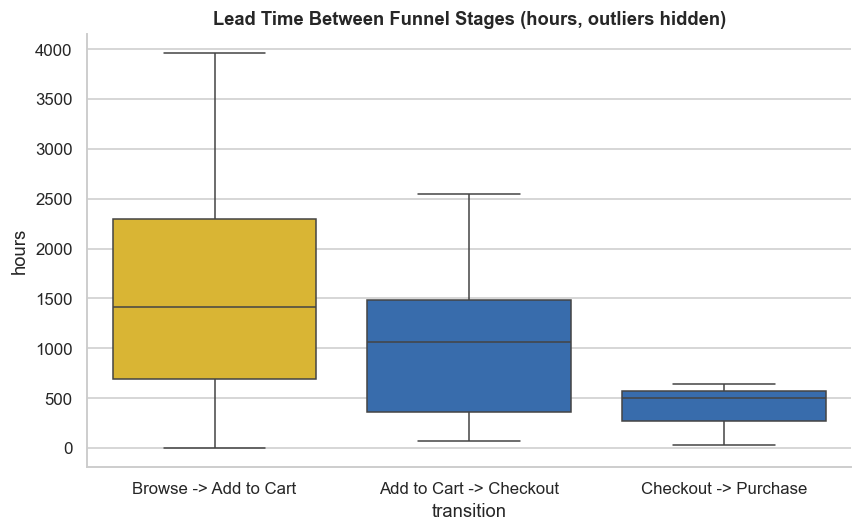

Longest average lead time: Browse -> Add to Cart (1558h, n=539)


In [ ]:
order_t = [f'{stage_names[a]} -> {stage_names[b]}' for a, b in [(1, 2), (2, 3), (3, 4)]]
longest = lt_summary['mean'].idxmax()
box_palette = {t: (BRAND_YELLOW if t == longest else SEQ_BLUE[4]) for t in order_t}

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=lead_time, x='transition', y='hours', order=order_t, ax=ax, palette=box_palette, hue='transition', legend=False, showfliers=False)
ax.set_title('Lead Time Between Funnel Stages (hours, outliers hidden)', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

print(f"Longest average lead time: {longest} ({lt_summary.loc[longest, 'mean']:.0f}h, n={lt_summary.loc[longest, 'count']:.0f})")


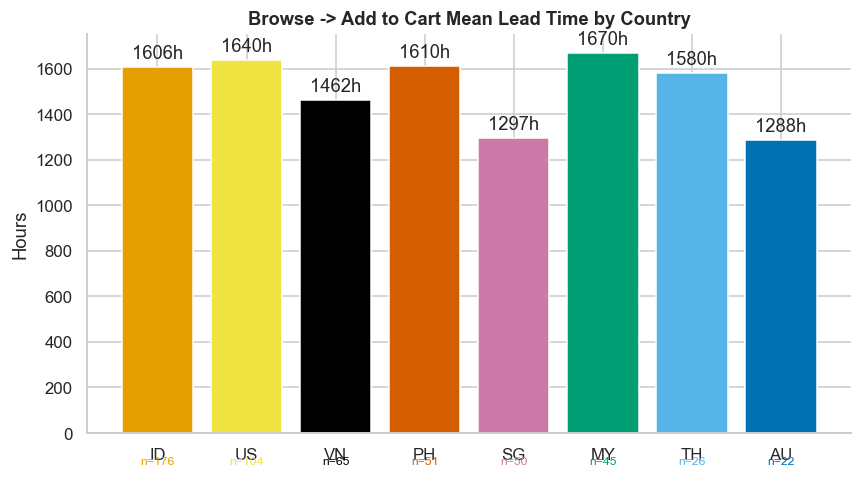

,count,mean,median
country,,,
ID,176,1606.3,1467.0
US,104,1639.5,1605.2
VN,65,1462.0,1208.6
PH,51,1610.2,1585.5
SG,50,1297.2,1084.1
MY,45,1670.2,1423.5
TH,26,1580.1,1469.1
AU,22,1287.5,990.9


In [ ]:
# Granular: lead time by country, as a bar chart (mean hours, n annotated). Only
# Browse -> Add to Cart has enough volume (n=539) to split across 8 countries -- Add to
# Cart -> Checkout (n=51) and Checkout -> Purchase (n=3) are too thin to break down
# further.
bta = lead_time[lead_time['transition'] == 'Browse -> Add to Cart']
bta_country = bta.groupby('country')['hours'].agg(['count', 'mean', 'median']).round(1)
bta_country = bta_country.sort_values('count', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(bta_country.index, bta_country['mean'], color=[COUNTRY_COLORS[c] for c in bta_country.index])
ax.bar_label(bars, fmt='%.0fh', padding=3)
ax.set_title('Browse -> Add to Cart Mean Lead Time by Country', fontweight='bold')
ax.set_ylabel('Hours')
for i, country in enumerate(bta_country.index):
    ax.text(i, ax.get_ylim()[1] * -0.06, f"n={int(bta_country.loc[country, 'count'])}", ha='center', va='top',
            fontsize=8, color=COUNTRY_COLORS[country])
sns.despine()
plt.tight_layout()
plt.show()

bta_country


**Answer:** **Browse -> Add to Cart** is the longest and best-supported gap (~65 days avg,
n=539) -- this is the stage to prioritize (e.g. retargeting browsers who didn't add to
cart). **Caution:** `Checkout -> Purchase` has only ~3 qualifying cases -- too few to draw
any conclusion from; don't read its number as representative.


## STEP 11 — Best-Selling Products

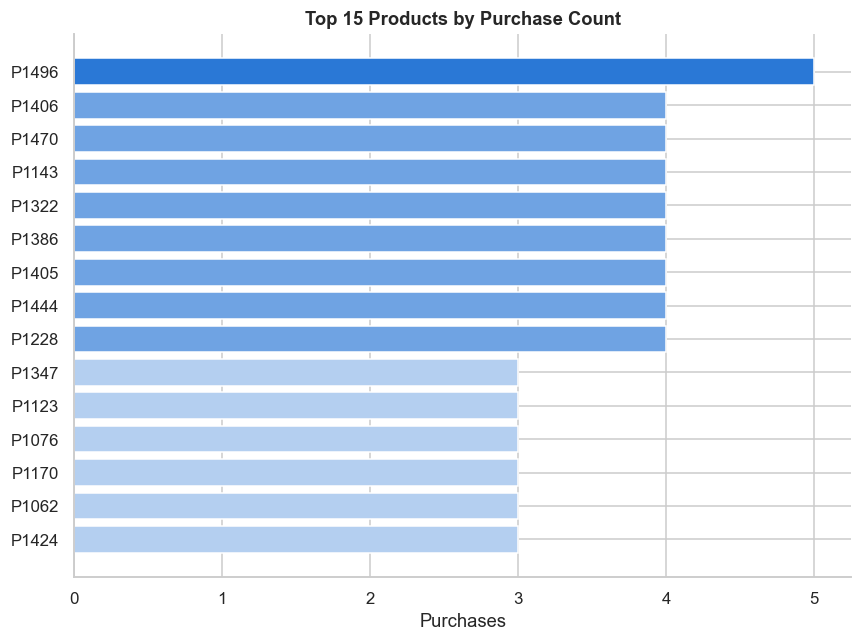

In [ ]:
purchases = df[df['event_type'] == 'purchase']
top_products = purchases['product_id'].value_counts().head(15)

norm = (top_products.values - top_products.values.min()) / (top_products.values.max() - top_products.values.min() + 1e-9)
colors = [blend_with_white(BLUE, 0.35 + 0.65 * n) for n in norm][::-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_products.index[::-1], top_products.values[::-1], color=colors)
ax.set_title('Top 15 Products by Purchase Count', fontweight='bold')
ax.set_xlabel('Purchases')
sns.despine()
plt.tight_layout()
plt.show()


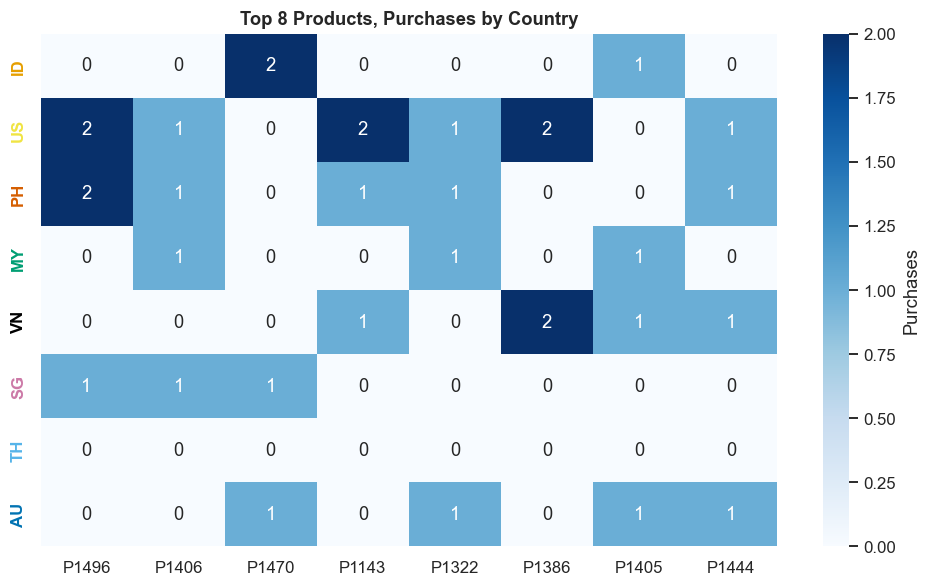

In [ ]:
# Granular: purchase count for the top 8 overall products, split by country, as a
# heatmap (rows ordered by that country's total purchase volume, high -> low).
top8 = top_products.head(8).index.tolist()
country_purchase_totals = purchases['country'].value_counts()
product_by_country = pd.crosstab(purchases['country'], purchases['product_id'])
product_by_country = product_by_country.reindex(index=country_purchase_totals.index, columns=top8).fillna(0)

fig, ax = plt.subplots(figsize=(9, 0.5 * len(product_by_country) + 1.5))
sns.heatmap(product_by_country, annot=True, fmt='.0f', cmap='Blues', ax=ax, cbar_kws={'label': 'Purchases'})
ax.set_title('Top 8 Products, Purchases by Country', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
for tick, country in zip(ax.get_yticklabels(), product_by_country.index):
    tick.set_color(COUNTRY_COLORS[country])
    tick.set_fontweight('bold')
plt.tight_layout()
plt.show()


## STEP 12 — Purchase Pattern by Day of Week & Hour

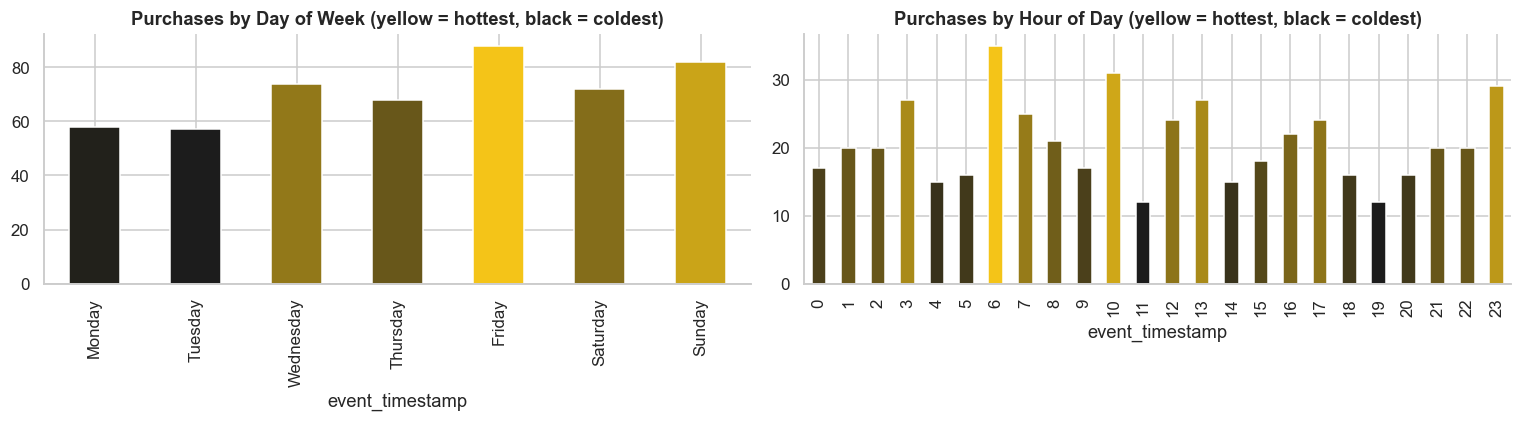

In [ ]:
purchases_dow = purchases['event_timestamp'].dt.day_name()
dow_counts = purchases_dow.value_counts().reindex(DOW_ORDER)
dow_norm = (dow_counts.values - dow_counts.values.min()) / (dow_counts.values.max() - dow_counts.values.min() + 1e-9)
dow_bar_colors = [blend_two(BEE_BLACK, BRAND_YELLOW, n) for n in dow_norm]  # bee hotness scale: high -> yellow, low -> black

hour_counts = purchases['event_timestamp'].dt.hour.value_counts().sort_index()
hour_norm = (hour_counts.values - hour_counts.values.min()) / (hour_counts.values.max() - hour_counts.values.min() + 1e-9)
hour_bar_colors = [blend_two(BEE_BLACK, BRAND_YELLOW, n) for n in hour_norm]  # bee hotness scale: high -> yellow, low -> black

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
dow_counts.plot(kind='bar', ax=axes[0], color=dow_bar_colors)
axes[0].set_title('Purchases by Day of Week (yellow = hottest, black = coldest)', fontweight='bold')
hour_counts.plot(kind='bar', ax=axes[1], color=hour_bar_colors)
axes[1].set_title('Purchases by Hour of Day (yellow = hottest, black = coldest)', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()


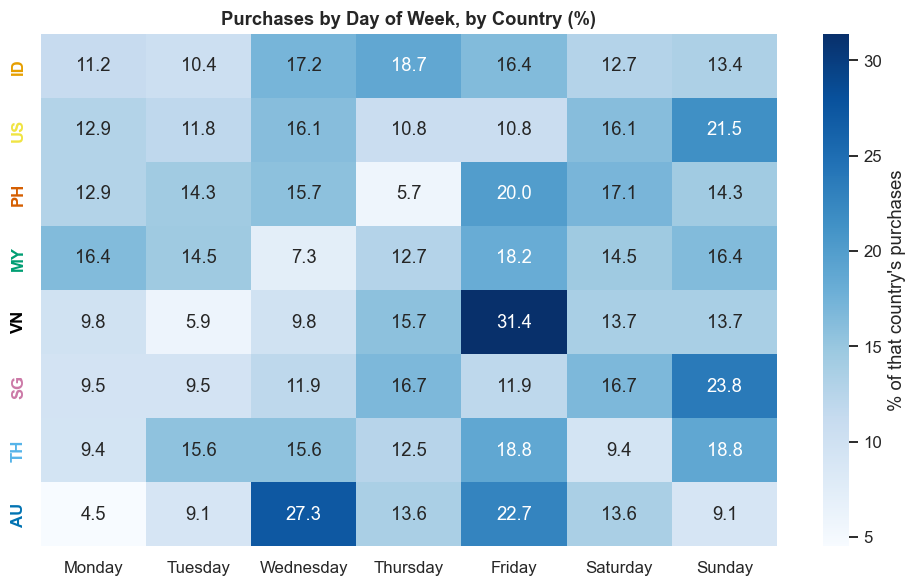

In [ ]:
# Granular: day-of-week pattern split by country, as a heatmap (% within each country's
# own purchases, so countries with different volumes are still comparable). Rows
# ordered by total purchase volume, high -> low.
country_purchase_counts = purchases['country'].value_counts()
country_order_pp = country_purchase_counts.index.tolist()

dow_by_country = pd.crosstab(purchases['country'], purchases['event_timestamp'].dt.day_name(), normalize='index') * 100
dow_by_country = dow_by_country.reindex(index=country_order_pp, columns=DOW_ORDER)

fig, ax = plt.subplots(figsize=(9, 0.5 * len(country_order_pp) + 1.5))
sns.heatmap(dow_by_country.round(1), annot=True, fmt='.1f', cmap='Blues', ax=ax,
            cbar_kws={'label': "% of that country's purchases"})
ax.set_title('Purchases by Day of Week, by Country (%)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
for tick, country in zip(ax.get_yticklabels(), country_order_pp):
    tick.set_color(COUNTRY_COLORS[country])
    tick.set_fontweight('bold')
plt.tight_layout()
plt.show()


## STEP 13 — Behavior: Added to Cart but Never Purchased
Definition: a user who has >=1 `add_to_cart` event but no `purchase` event anywhere in
the log (no order/cart id exists to link a specific cart item to a specific purchase, so
this is measured at the user level).

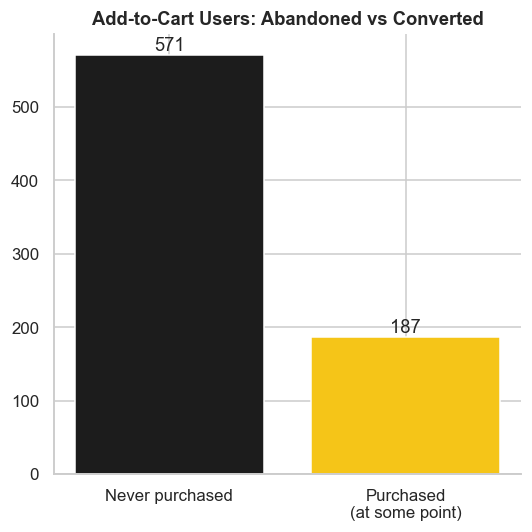

571 / 758 add-to-cart users never purchased (75.3%)


In [ ]:
atc_users = set(df[df['event_type'] == 'add_to_cart']['user_id'])
purchase_users = set(df[df['event_type'] == 'purchase']['user_id'])
abandoned_users = atc_users - purchase_users
converted_users = atc_users & purchase_users
rate = len(abandoned_users) / len(atc_users)

fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(['Never purchased', 'Purchased\n(at some point)'], [len(abandoned_users), len(converted_users)], color=[BEE_BLACK, BRAND_YELLOW])
ax.set_title('Add-to-Cart Users: Abandoned vs Converted', fontweight='bold')
for i, v in enumerate([len(abandoned_users), len(converted_users)]):
    ax.text(i, v, str(v), ha='center', va='bottom')
sns.despine()
plt.tight_layout()
plt.show()

print(f'{len(abandoned_users)} / {len(atc_users)} add-to-cart users never purchased ({rate:.1%})')


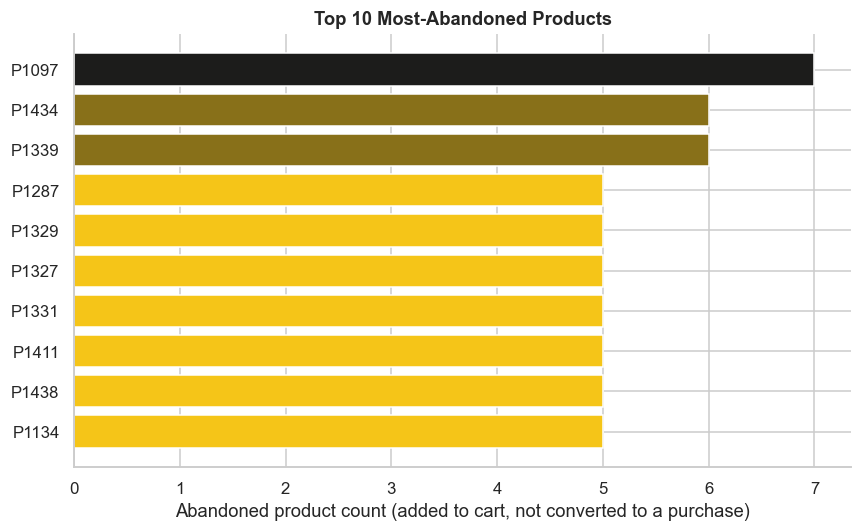

In [ ]:
atc_prod = df[df['event_type'] == 'add_to_cart']['product_id'].value_counts()
purch_prod = df[df['event_type'] == 'purchase']['product_id'].value_counts()
abandoned_product = (atc_prod - purch_prod.reindex(atc_prod.index).fillna(0)).sort_values(ascending=False).head(10)

gap_norm = (abandoned_product.values - abandoned_product.values.min()) / (abandoned_product.values.max() - abandoned_product.values.min() + 1e-9)
gap_colors = [blend_two(BRAND_YELLOW, BEE_BLACK, n) for n in gap_norm][::-1]  # bee severity ramp: worse gap -> black

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(abandoned_product.index[::-1], abandoned_product.values[::-1], color=gap_colors)
ax.set_title('Top 10 Most-Abandoned Products', fontweight='bold')
ax.set_xlabel('Abandoned product count (added to cart, not converted to a purchase)')
sns.despine()
plt.tight_layout()
plt.show()


**Answer:** 75% of users who ever added something to cart never completed a purchase -- the largest single leak in the funnel. The product list above is where to start investigating (pricing, stock, description, or page UX).

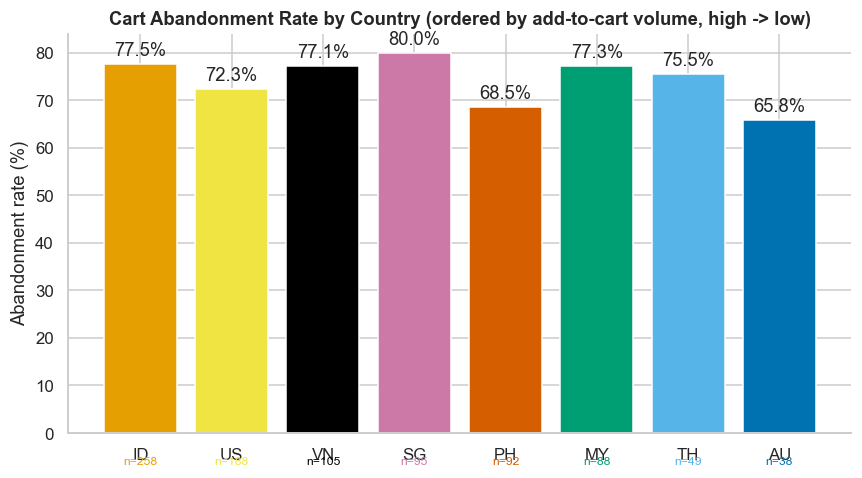

,atc_users,abandoned,rate
country,,,
ID,258,200,77.519380
US,188,136,72.340426
VN,105,81,77.142857
SG,95,76,80.000000
PH,92,63,68.478261
MY,88,68,77.272727
TH,49,37,75.510204
AU,38,25,65.789474


In [ ]:
# Granular: cart-abandonment rate split by country, as a bar chart (rows ordered by
# add-to-cart volume, high -> low). Country is per-event, not per-user (like device),
# so this anchors on the country of the add_to_cart event, but checks conversion
# against that user's purchases ANYWHERE -- not requiring the purchase event to carry
# the same country tag, which would undercount users who converted under a different tag.
atc_by_country = df[df['event_type'] == 'add_to_cart'].groupby('country')['user_id'].apply(set)
all_purchase_users = set(df[df['event_type'] == 'purchase']['user_id'])

rows = []
for country in df['country'].unique():
    atc_set = atc_by_country.get(country, set())
    if atc_set:
        abandoned = atc_set - all_purchase_users
        rows.append({'country': country, 'atc_users': len(atc_set),
                     'abandoned': len(abandoned), 'rate': len(abandoned) / len(atc_set) * 100})
abandon_by_country = pd.DataFrame(rows).set_index('country').sort_values('atc_users', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(abandon_by_country.index, abandon_by_country['rate'],
              color=[COUNTRY_COLORS[c] for c in abandon_by_country.index])
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_title('Cart Abandonment Rate by Country (ordered by add-to-cart volume, high -> low)', fontweight='bold')
ax.set_ylabel('Abandonment rate (%)')
for i, country in enumerate(abandon_by_country.index):
    ax.text(i, ax.get_ylim()[1] * -0.06, f"n={int(abandon_by_country.loc[country, 'atc_users'])}", ha='center', va='top',
            fontsize=8, color=COUNTRY_COLORS[country])
sns.despine()
plt.tight_layout()
plt.show()

abandon_by_country


## STEP 14 — Summary & Recommendations

1. **Indonesia** leads in Q2 2025 active users (STEP 05) -- highest-leverage market for
   conversion tests.
2. **Android** dominates sessions (STEP 07), but device doesn't gate specific actions --
   no device-specific funnel fix is indicated by usage alone.
3. **Cart abandonment is the single biggest leak: 75% of add-to-cart users never
   purchase** (STEP 13). Prioritize cart-recovery: abandonment emails/push, and review
   the top-gap products for pricing/stock/description issues.
4. **Browse -> Add to Cart is the slowest stage** (STEP 10, ~65 days avg, largest sample)
   -- retarget users who browsed but didn't add to cart, rather than assuming the
   bottleneck is late-funnel (checkout/payment).
5. **Cart -> Checkout vs Checkout -> Purchase** (STEP 09) pinpoints whether the
   remaining friction is pre-payment (pricing/shipping surprise) or payment-flow itself.